<a href="https://colab.research.google.com/github/Afosoriol647/Telecommunications-Company---Data-Cleanning-and-Insights-/blob/main/Telecommunications_CompanyDataCleanning_and_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, el objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello usaremos 3 datasets:

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

**Objetivo**

 **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

---
## 🧩 Paso 1: Cargar y explorar


### 1.1 Carga de datos y vista rápida




In [ ]:
# importar librerías

#importar pandas
import pandas as pd

#importar numpy
import numpy as np

#importar seaborn
import seaborn as sns

#importar matplotlib
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets
revisar cuántas filas y columnas tienen
identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.


In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.



In [ ]:
# cantidad de nulos para users


print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:

#conteo por categoria 'city' valores nulos
users['city'].value_counts()


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
#indagando valores '?'
users[users['city'].isin(["?"])]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
83,10083,Mariana,Garcia,50,?,2022-01-23 17:26:46.901725431,Basico,NaN
160,10160,Luis,Torres,29,?,2022-02-13 19:27:46.316579145,Basico,NaN
161,10161,Luis,Gomez,22,?,2022-02-14 02:02:04.231057764,Basico,NaN
186,10186,Mateo,Torres,28,?,2022-02-20 22:19:32.093023256,Basico,NaN
...,...,...,...,...,...,...,...,...
3882,13882,Carlos,Torres,35,?,2024-11-28 23:07:04.006001504,Premium,NaN
3889,13889,Carlos,Lopez,77,?,2024-11-30 21:07:09.407351840,Premium,NaN
3901,13901,Mariana,Lopez,56,?,2024-12-04 03:58:44.381095280,Basico,NaN
3955,13955,Ana,Lopez,59,?,2024-12-18 22:50:51.762940736,Basico,NaN


In [ ]:
#conteo por categoria/columna 'churn_date' con valores nulos
users['churn_date'].value_counts()


1,71763E+18    6
1,71841E+18    6
1,72238E+18    6
1,72912E+18    5
1,72463E+18    5
              ..
1,72765E+18    1
1,72662E+18    1
1,72541E+18    1
1,72411E+18    1
1,72368E+18    1
Name: churn_date, Length: 197, dtype: int64

In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos
print(usage.isna().mean())# Proporción de valores nulos


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentarios**:

- Respecto al dataframe `users` encontramos que `city` y `churn_date` contienen valores nulos, 11.7% y 88.3% respectivamente, se recomienda que se investigue para imputar o dejar como nulos el primero y el segundo se recomienda eliminar.
  
- Respecto al dataframe `usage` encontramos que `date`,  `duration` y `lenght` contienen valores nulos, 0.12%, 55.19%  y 44.74% respectivamente, se recomienda dejar como nulos y para “duration” y “lenght” investigar para imputar o dejar como nulos (al ser tiempo es posible que se deba transformar en el formato correcto para que pueda ser usado correctamente)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users['user_id'].describe()

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

In [ ]:
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` muestra valores esperados de una numeración que empieza en 10.000 y va hasta 13.999 (Count 4.000),  no se parecian outlier o sentinels.  
- La columna `age` el valor que mas llama la atención es el sentinel que aparece como valor minimo (-999) se debe corregir este sentinel por medio de winzorización, de resto los datos se encuentran en un rango tipico de edades de un ser humano.

In [ ]:
# explorar columnas numéricas de
usage['user_id'].describe()

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

In [ ]:
usage['id'].describe()

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

- Las columna `id` muestra valores esperados de una numeración que empieza en 1 y va hasta 4.000 (Count 4.000), no se parecian outlier o sentinels.
- Las columna `user_id`  muestra valores esperados de una numeración que empieza en 10.000 y va hasta 13.999 (Count 4.000), no se parecian outlier o sentinels.


In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` contiene 3.531 alores no nulos, al categorizar tenemos 7 elementos unicos y el elemento que mas aparece (808) es Bogotá
- La columna `plan` Contiene 4.000 valores no nulos, al categorizarlos tenemos 2 elementos unicos (Premium y Basico) y el elemento que mas aparece (2.595 veces) es Basico

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene 4.000 valores no nulos, están categorizados en dos grupos ( "text" y "call") y "text" es la categoria que aparece en mayor proporción.


---
✍️ **Comentarios**

Con respecto al dataframe **users**:
1. La columna `age` el valor que mas llama la atención es el outliner que aparece como valor minimo (-999)
2. La columna `city` aparece con valores inválidos, al revisar mas a detalle encontramos nombres mal escritos y 96  valores tipo “sentinels”
3. La comuna `churn_date` contiene 3.534 valores nulos

Con respecto al dataframe **usage**:
1. Se encontraron Valores nulos en `date`, `duration` and `lenght`

- Acción a tomar
  
Con respecto al dataframe **users**:
1. La columna `age` se debe "capar" el outliner por medio de winzorización, de resto los datos se encuentran en un rango típico de edades de un ser humano.
2. La columna `city` debe estandarizar nombres y los valores incognitos convertirlos en NaN
3. La comuna `churn_date`  se deben convertir los datos en formato de fecha si la columna es relevante para las preguntas del negocio

Con respecto al dataframe **usage**:
1. Convertir a formato fecha las siguientes columnas `date`, `duration` and `lenght`


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce", utc=True)
print(users['reg_date'].dtype)

datetime64[ns, UTC]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce", utc=True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

In [ ]:
users['reg_date'].isna().sum()

0

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

In [ ]:
usage['date'].isna().sum()

50

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentarios**:
Transformamos el formato de fechas para la columna de `date` del data frame de usage y la columna `reg_date` del df users, para el primero encontramos que 3.9950 datos se encuentran dentro del rango de 2024 y encontramos 50 valores nulos. Por otro lado en la columna `reg_date` encontramos 40 lineas en el 2026. Se recomienda Marcar fechas futuras como NA ya que se encuentran por fuera del rango establecido y podrían afectar negativamente los datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace("?","NA")

# Verificar cambios
users['city'].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date

#  marcamos fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Daignostico**

los nulos en la columna `duration` y `lenght` son **MAR (la ausencia depende de otra variable que sí puedes observar)** ya que dependen de la categorización de la columa Type, tiene sentido ya que los mensajes no se miden en duración, se miden en numero de caracteres (texto) y las llamadas de telefono no tienen un numero de caracteres se miden es por duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Proceso:**
1. Construcción de tabla agregada de `usage` por `user_id` que incluye:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombre de columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combinación con tabla `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call",'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on= 'user_id', how='inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Resumen estadístico para las columnas **numéricas** relevantes.
2. revisión de la distribución en **porcentajes** de cada categoría para la columna **categórica** `plan`.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.124531
std,1154.898108,2.358416,2.144238,18.168095,17.692032
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,47.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True)*100)

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas y realizar comentarios:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`



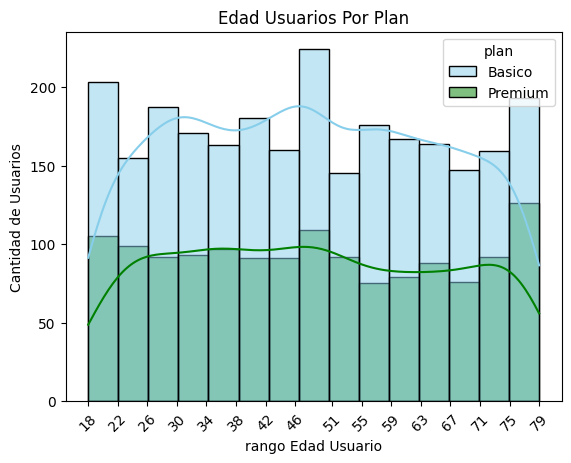

In [ ]:



# Histograma para visualizar la edad (age)
_, bin_edges = np.histogram(user_profile['age'], bins=15)
sns.histplot(user_profile, x='age', bins=15, palette=['skyblue','green'], hue='plan', kde=True)

plt.xlabel('rango Edad Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.title('Edad Usuarios Por Plan')

plt.xticks(np.round(bin_edges).astype(int), rotation=45)
plt.show()




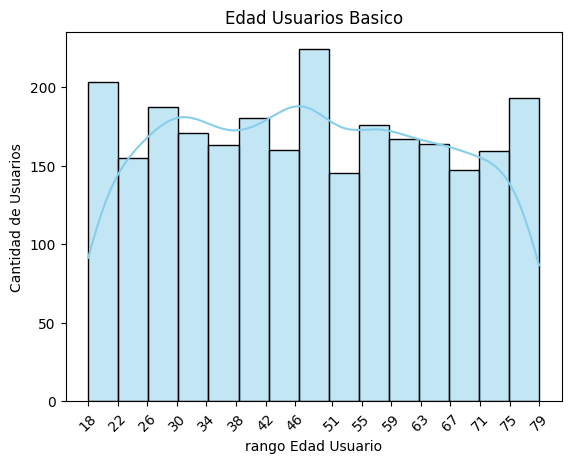

In [ ]:


# Histograma para visualizar la edad (age) solo para Basico
basico = user_profile[user_profile['plan'] == 'Basico']

_, bin_edges = np.histogram(user_profile['age'], bins=15)
sns.histplot(basico, x='age', bins=15, color='skyblue', kde=True)

plt.xlabel('rango Edad Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.title('Edad Usuarios Basico')

plt.xticks(np.round(bin_edges).astype(int), rotation=45)
plt.show()




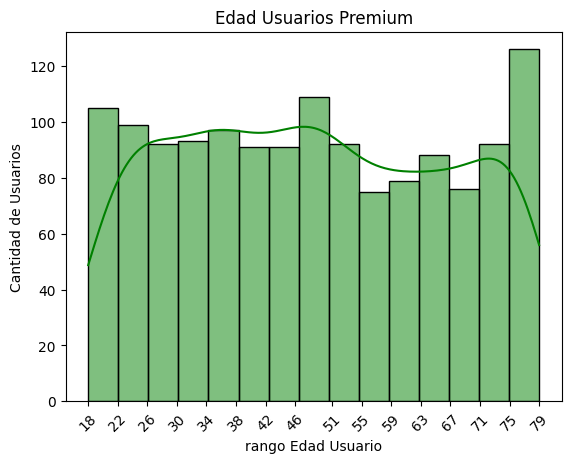

In [ ]:
# Histograma para visualizar la edad (age) solo para Basico
#filtrado solo premium
basico = user_profile[user_profile['plan'] == 'Premium']

_, bin_edges = np.histogram(user_profile['age'], bins=15)
sns.histplot(basico, x='age', bins=15,color='green', kde=True)

plt.xlabel('rango Edad Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.title('Edad Usuarios Premium')

plt.xticks(np.round(bin_edges).astype(int), rotation=45)
plt.show()

💡Insights:
- al momento de comparar la distribución del plan Premium y Básico encontramos que No existe algún patrón relevante aparte de que existe un mayor numero de usuarios en la categoria basica, la cantidad de usuarios por edad se mantiene balanceada en la mayoría de rangos de edad, lo que podemos resaltar es que hay un alto número de usuarios en ambos planes en el rango de edad de 46-51 años seguido de 18-22 años.

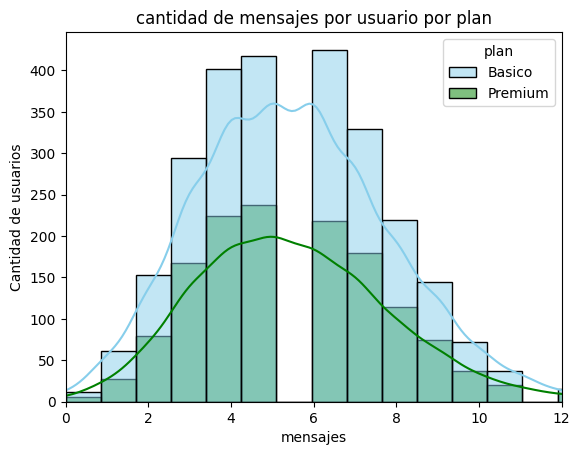

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(user_profile, x='cant_mensajes', bins=20, palette=['skyblue','green'], hue='plan', kde=True)
plt.xlim(0, 12)
plt.xlabel('mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('cantidad de mensajes por usuario por plan')

plt.show()


💡Insights:
- Con respecto a la cantidad de mensajes por plan encontramos un comportamiento simétrico en forma de campana de Gaus, donde los valores máximos se encuentran entre 4 a 7 mensajes. con respecto al plan, este no influye mucho en la frecuencia de mensajes

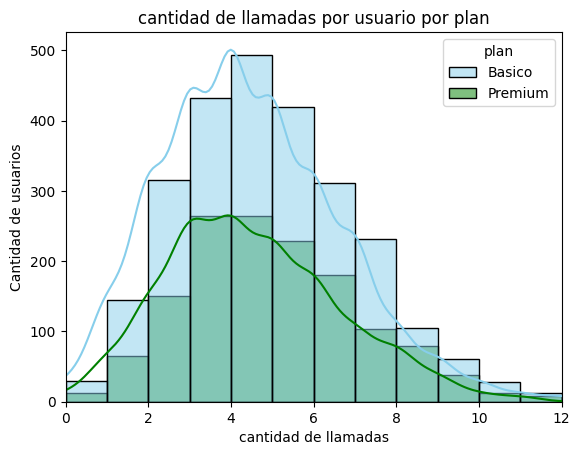

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(user_profile, x='cant_llamadas', bins=15, palette=['skyblue','green'], hue='plan', kde=True)
plt.xlim(0, 12)
plt.xlabel('cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('cantidad de llamadas por usuario por plan')

plt.show()

💡Insights:
- Con respecto a la cantidad de llamadas por plan encontramos un comportamiento asimétrico sesgado hacia la derecha en forma de campana, donde los valores máximos son 3 a 6 llamadas. Se mantiene la tendencia de mayor numero de usuarios con plan básico.

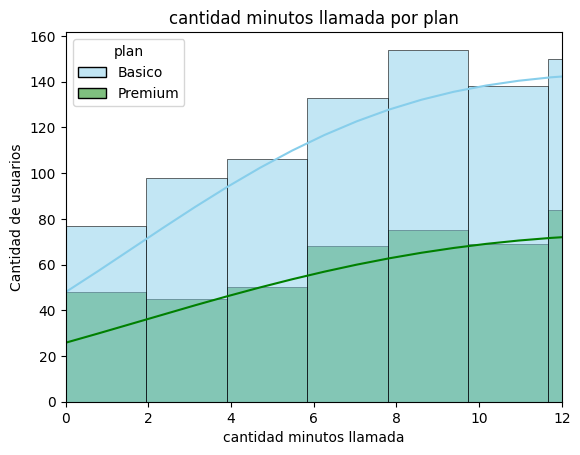

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', bins=80, palette=['skyblue','green'], hue='plan', kde=True)
plt.xlim(0, 12)
plt.xlabel('cantidad minutos llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('cantidad minutos llamada por plan')

plt.show()

💡Insights:
- Con respecto a la cantidad de minutos por  por plan encontramos un comportamiento asimétrico sesgado hacia la izquierda donde los valores máximos son 8 a 10 minutos por llamada. Se mantiene la tendencia de mayor número de usuarios con plan básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Uso de  **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  


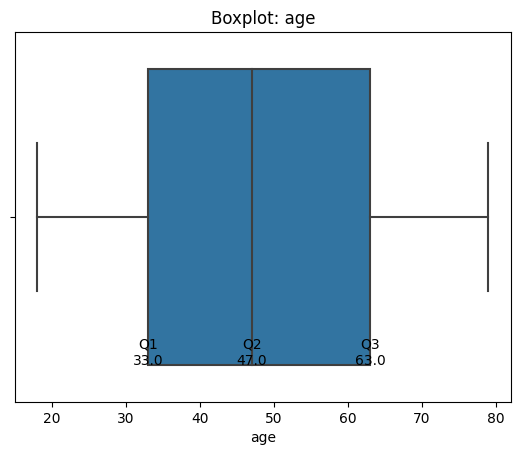

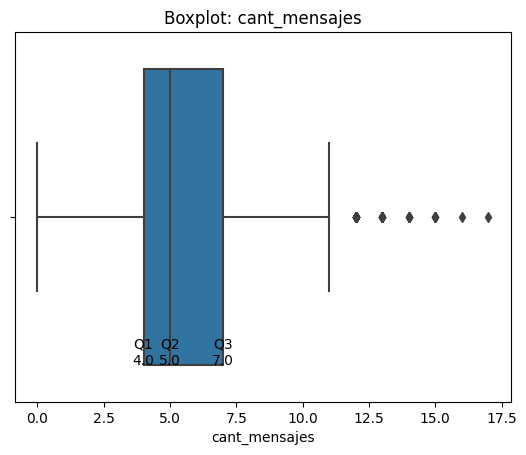

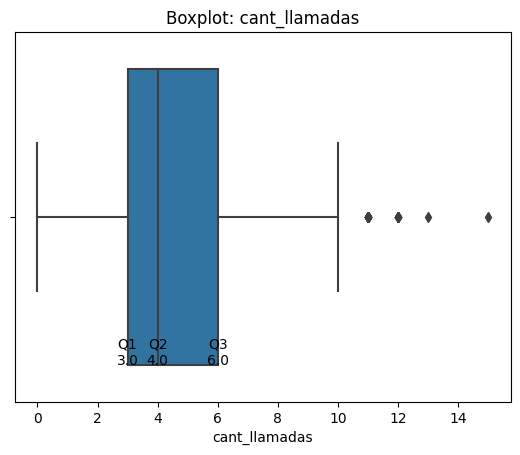

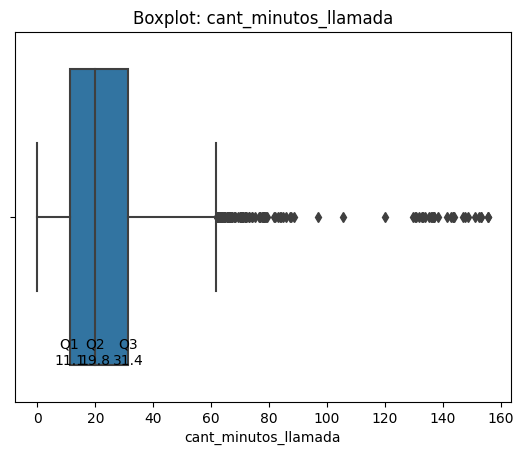

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    ax = sns.boxplot(data=user_profile, x=col)

    q1  = user_profile[col].quantile(0.25)  #Cuartil inferior (q1)
    q2  = user_profile[col].quantile(0.50)  # mediana
    q3  = user_profile[col].quantile(0.75)

    for valor, etiqueta in zip([q1, q2, q3], ['Q1', 'Q2', 'Q3']):
        ax.text(valor, 0.4, f'{etiqueta}\n{valor:.1f}',
                ha='center', fontsize=10, color='black')

    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:

**•Age:**

-La mediana está en valores adecuados dentro de la distribución de edad indicando que la mitad de los usuarios tienen una edad media de 47años.

-La caja (IQR) es angosta: las edades están distribuidas dentro de un rango amplio.

-Los bigotes muestran el rango típico de valores (18- 85 años).

-No encontramos valores atípicos leves o extremos en esta visualización.

**cant_mensajes:**

-La mediana está en valores bajos, indicando que la mitad de la cantidad de mensajes enviadas por usuarios son pequeñas (5 mensajes).

-La caja (IQR) es estrecha: la mayoría de la cantidad de mensajes enviados concentrados en un rango de 4 a 7 mensajes.

-Los bigotes muestran el rango típico de valores sin considerar anomalías (0 – 11 mensajes).

-Los puntos aislados a la derecha son outliers leves (11 a 17 mensajes), que revelan una cola derecha.


**cant_llamadas:**

-La mediana está en valores bajos, indicando que la mitad de la cantidad de llamandas son mínimas ( 4 llamadas).

-La caja (IQR) es estrecha: la mayoría de la cantidad de llamandas están concentrados en un rango reducido (3 a 6 llamadas)

-Los bigotes muestran el rango típico de valores sin considerar anomalías (0 – 10 llamadas).

-Los puntos aislados a la derecha son outliers leves (10 a 15 llamadas), que revelan una cola hacia la derecha.

**cant_minutos_llamada:**

-La mediana está en valores bajos, indicando que la mitad de la cantidad de minutos por  llamada son  19 minutos.

-La caja (IQR) es estrecha: la mayoría de minutos por  llamada están concentrados en un rango reducido (11.1 a 31.4 min x llamada).

-Los bigotes muestran el rango típico de valores sin considerar anomalías (0 – 60 minutos llamadas).

-Los puntos aislados a la derecha son outliers altos (60 a 160 min x llamadas), que revelan una cola derecha larga.


In [ ]:
# Calcular límites con el método IQR IQR = Q3 - Q1
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    #obtener el rango intercuartílico.
    IQR = Q3 - Q1
    #obtener limite inferior.
    lower = Q1 - 1.5 * IQR

    #calcular límite superior
    upper = Q3 + 1.5 * IQR

    print(col,'IQR: ',IQR)
    print(col,'limite Inferior: ',lower)
    print(col,'limite Superior: ',upper)


cant_mensajes IQR:  3.0
cant_mensajes limite Inferior:  -0.5
cant_mensajes limite Superior:  11.5
cant_llamadas IQR:  3.0
cant_llamadas limite Inferior:  -1.5
cant_llamadas limite Superior:  10.5
cant_minutos_llamada IQR:  20.295
cant_minutos_llamada limite Inferior:  -19.322500000000005
cant_minutos_llamada limite Superior:  61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes:

IQR  en 3.0 , valores menores a -0.5  y mayores a 11.5 deben ser considerados ouliers   o valores atípicos, en este caso tenemos valores máximos que sobrepasan este límite (17), considero que no debería eliminarse ya que nos está indicando que hay usuarios que usan mensajería de manera constante.

- cant_llamadas: mantener o no outliers, porqué?

IQR  en 3.0 , valores menores a -1.5  y mayores a 10.5 deben ser considerados ouliers   o valores atípicos, en este caso tenemos valores máximos que sobrepasan este límite (15), considero que no debería eliminarse ya que nos está indicando que hay usuarios que hacen más llamadas, por lo que sería una oportunidad para crear planes para usuarios que realicen más llamadas a un mejor costo.

- cant_minutos_llamada: mantener o no outliers, porqué?
  
IQR  en 20.29 , valores menores a -19.32  y mayores a 61.5 deben ser considerados ouliers   o valores atípicos, en este caso tenemos valores máximos que sobrepasan este límite (155), considero que no debería eliminarse ya que nos está indicando que hay usuarios que consumen muchos minutos en una llamada.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Proceso de Filtrado:**  
- Creación de nueva columna  `grupo_uso` en el dataframe `user_profile`.
- Uso de comparaciones lógicas para clasificar por uso:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def classify_By_Usage(row):
    cant_mensajes = row['cant_mensajes']
    cant_llamadas = row['cant_llamadas']

    if cant_llamadas < 5 and cant_mensajes < 5:
        return 'Bajo uso'
    elif cant_llamadas < 10 and cant_mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(classify_By_Usage, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Proceso de Filtrado:**  
- Creación de  nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Uso de  comparaciones lógicas (<, >) para evaluar las condiciones de la siguiente manera:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def classify_By_Age(row):
    age = row['age']

    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(classify_By_Age,axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Proceso:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.


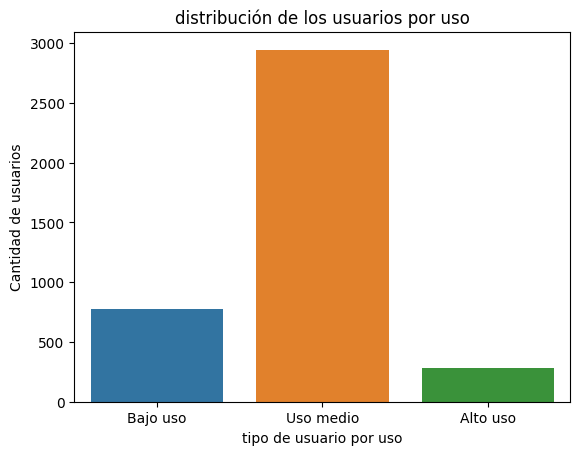

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso",order=["Bajo uso", "Uso medio", "Alto uso"])

plt.xlabel('tipo de usuario por uso')
plt.ylabel('Cantidad de usuarios')
plt.title('distribución de los usuarios por uso')
plt.show()

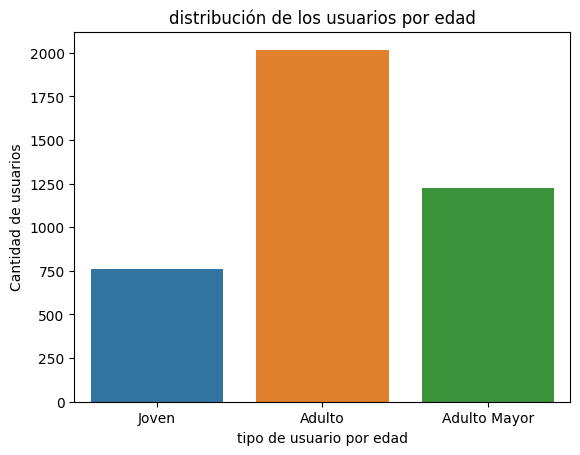

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad",order=["Joven", "Adulto", "Adulto Mayor"])

plt.xlabel('tipo de usuario por edad')
plt.ylabel('Cantidad de usuarios')
plt.title('distribución de los usuarios por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
De las 3 bases de datos compartidas encontramos varias inconsistencias:

-En “users” encontramos que las columnas “city” y “churn_date” contienen valores nulos, 11.7% y 88.3% respectivamente

-Con respecto al dataframe “usage” encontramos que “date”, “duration” y “lenght” contienen valores nulos, 0.12%, 55.19% y 44.74% respectivamente, Date tenia un outliner de “-999” que fue ajustado y estandarizado toda la data en formato de fecha.



🔍 **Segmentos por Edad**
- Con respecto a la edad clasificamos a los usuarios como joven si es menor a 30 años, adulto si es menor a 60 y los que están por encima de ese número son Adultos mayores.
- al momento de analizar la edad de los usuarios nos percatamos de que las personas adultas son la mayoría de usuarios del servicio seguido por el adulto mayor  y finalmente por jóvenes.


📊 **Segmentos por Nivel de Uso**
- por uso, 'Bajo uso' cuando llamadas y mensajes   son menores a 5 , 'Uso medio' cuando llamadas y mensajes eran menores a 10  y 'Alto uso' para el resto de casos mayores a 10.
- Al graficar nos percatamos que la mayoría de los usuarios de la empresa de telecomunicaciones son personas que  máximo realizan 10 llamadas y envían 10 mensajes seguido por usuarios que realizan 5 llamadas y envían 5 mensajes.


➡️ Esto sugiere que Los segmentos mas valiosos que identificamos son el segmento de uso alto-medio y las edades de adulto mayor y adulto debido a que son los segmento mas numerosos y relevantes al momento de visualizar las graficas, por lo que todas las estrategias deben estar enfocadas en atraer / mantener estos usuarios.

Encontramos outliers leves en la cantidad de mensajes, cantidad de llamadas y cantidad de minutos por llamada, esto implica que hay ciertos usuarios que realizan más llamadas, envían textos y consumen una alta cantidad de minutos. Estos usuarios deben ser investigados para identificar el por qué de este comportamiento y crear planes que sean llamativos para este tipo de usuario.


💡 **Recomendaciones**
- Se recomienda establecer estrategias para los grupos más relevantes identificados, estos son los usuarios de uso medio-alto y usuarios de edad adulta – adulto mayor,  a través de estrategias que ofrezcan mas minutos y mensajes subiendo el precio en un 7%-10% al por los 3-5 primeros meses, agregar bundles con redes sociales y plataformas de streaming y sistemas de recompensas como llamadas y mensajes ilimitados a usuarios con tiempo considerable de suscripción.
  
- También recomendamos no descuidar los segmentos de bajo uso y jóvenes, ya que son propensos a convertirse en usuarios de medio-alto uso si se ofrecen planes e incentivos que les llamen la atención, como por ejemplo ofrecer mas minutos y mensajes en planes con un descuento inicial por 5 meses y después a precio completo. También se puede premiar la fidelidad con paquetes extras de minutos y mensajes para fomentar el consumo y motivar una mejora en los planes.